In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import xgboost as xgb

In [ ]:
df = pd.read_csv('diabetes_with_height_weight.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,HbA1c_level,blood_glucose_level,height_m,weight_kg,diabetes
0,Female,80.0,0,1,never,6.6,140,1.65,69.0,0
1,Female,54.0,0,0,No Info,6.6,80,1.61,70.8,0
2,Male,28.0,0,0,never,5.7,158,1.80,88.1,0
3,Female,36.0,0,0,current,5.0,155,1.73,69.9,0
4,Male,76.0,1,1,current,4.8,155,1.73,60.5,0


In [ ]:
 # -------------------------------
# CLEAN TEXT (IMPORTANT FIX)
# -------------------------------
df['gender'] = df['gender'].str.strip()
df['smoking_history'] = df['smoking_history'].str.strip()

# -------------------------------
# ENCODING
# -------------------------------
gender_map = {'Female': 0, 'Male': 1, 'Other': 2}

smoking_map = {
    'No Info': 0,
    'current': 1,
    'ever': 2,
    'former': 3,
    'never': 4,
    'not current': 5
}

df['gender'] = df['gender'].map(gender_map)
df['smoking_history'] = df['smoking_history'].map(smoking_map)

# -------------------------------
# SAFE HANDLING (DO NOT DROP ALL DATA)
# -------------------------------
df['gender'] = df['gender'].fillna(0)
df['smoking_history'] = df['smoking_history'].fillna(4)

print("After encoding shape:", df.shape)

# -------------------------------
# PREPROCESSING: MERGE HEIGHT & WEIGHT INTO BMI
# -------------------------------
# 1. Calculate BMI: weight / (height^2)
df['bmi'] = df['weight_kg'] / (df['height_m'] ** 2)
df['bmi'] = df['bmi'].round(2)

# 2. Remove height_m and weight_kg
df = df.drop(columns=['height_m', 'weight_kg'])

# 3. Reorder: Move BMI column before the diabetes column
cols = df.columns.tolist()
cols.remove('bmi')
cols.remove('diabetes')
new_order = cols + ['bmi', 'diabetes']
df = df[new_order]

print('Preprocessing Complete: Height and weight merged into BMI and repositioned.')
display(df.head())

After encoding shape: (100000, 10)
Preprocessing Complete: Height and weight merged into BMI and repositioned.


,gender,age,hypertension,heart_disease,smoking_history,HbA1c_level,blood_glucose_level,bmi,diabetes
0,0,80.0,0,1,4,6.6,140,25.34,0
1,0,54.0,0,0,0,6.6,80,27.31,0
2,1,28.0,0,0,4,5.7,158,27.19,0
3,0,36.0,0,0,1,5.0,155,23.36,0
4,1,76.0,1,1,1,4.8,155,20.21,0


In [ ]:
X = df[
    ['gender','age','hypertension','heart_disease',
     'smoking_history','bmi','HbA1c_level','blood_glucose_level']
]

# Rename to match Lambda
X.columns = ['gender','age','hypertension','heart_disease',
             'smoking_history','bmi','hba1c','glucose']

y = df['diabetes']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
import time
from sklearn.metrics import accuracy_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = []

for name, model in models.items():
    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    train_time = end - start

    results.append([name, acc, roc, train_time])

    print(f"{name} → Accuracy: {acc:.4f}, ROC-AUC: {roc:.4f}, Time: {train_time:.2f}s")

Logistic Regression → Accuracy: 0.9587, ROC-AUC: 0.9612, Time: 0.17s
Decision Tree → Accuracy: 0.9517, ROC-AUC: 0.8590, Time: 0.36s
Random Forest → Accuracy: 0.9710, ROC-AUC: 0.9661, Time: 9.95s
KNN → Accuracy: 0.9615, ROC-AUC: 0.9063, Time: 0.24s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:55:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost → Accuracy: 0.9714, ROC-AUC: 0.9785, Time: 0.59s


In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC", "Training Time"])
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC,Training Time
4,XGBoost,0.97140,0.978634,5.653841
2,Random Forest,0.97065,0.963585,9.055411
0,Logistic Regression,0.95870,0.961231,0.196579
3,KNN,0.96130,0.905706,0.341663
1,Decision Tree,0.95185,0.854353,0.339548


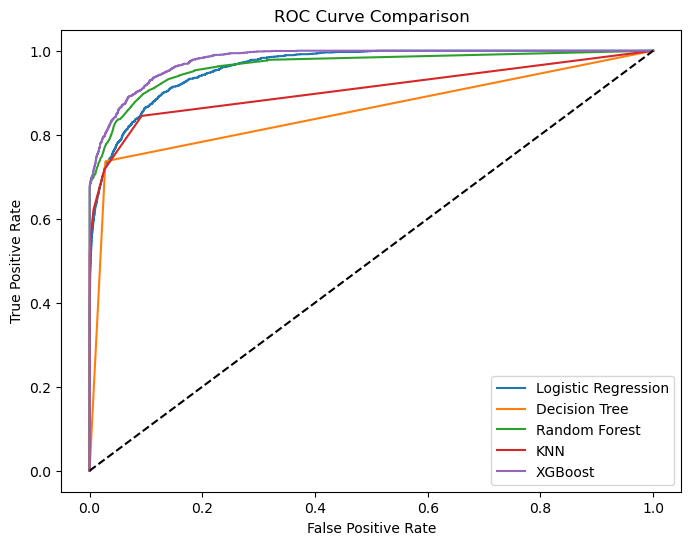

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

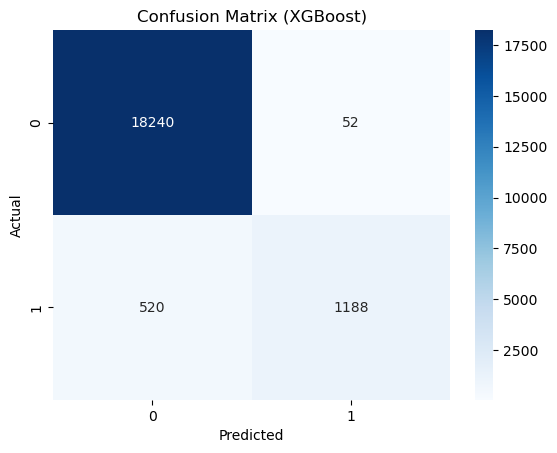

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Pick best model (usually XGBoost)
best_model = models["XGBoost"]

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pickle

# Save model
with open("model_fixed.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved!")

Model and scaler saved!


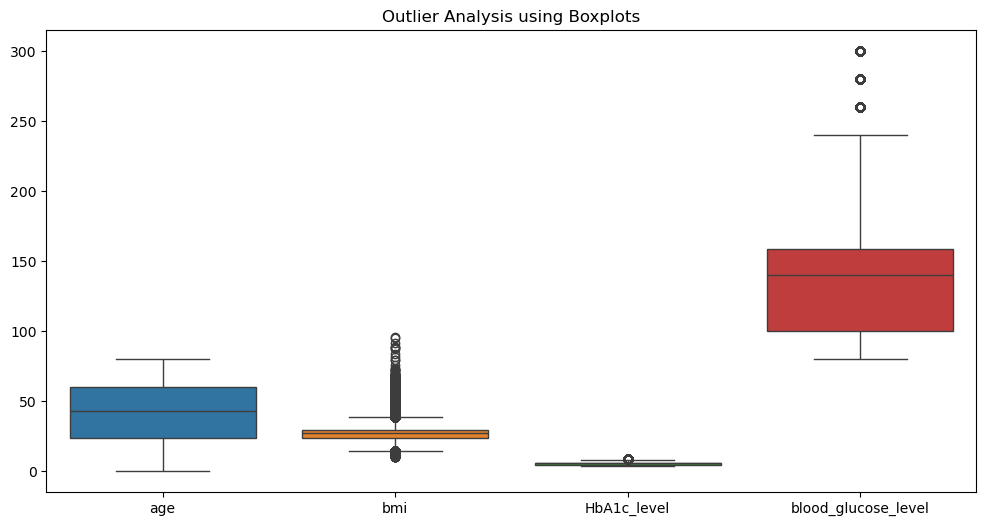

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[['age','bmi','HbA1c_level','blood_glucose_level']])
plt.title("Outlier Analysis using Boxplots")
plt.show()

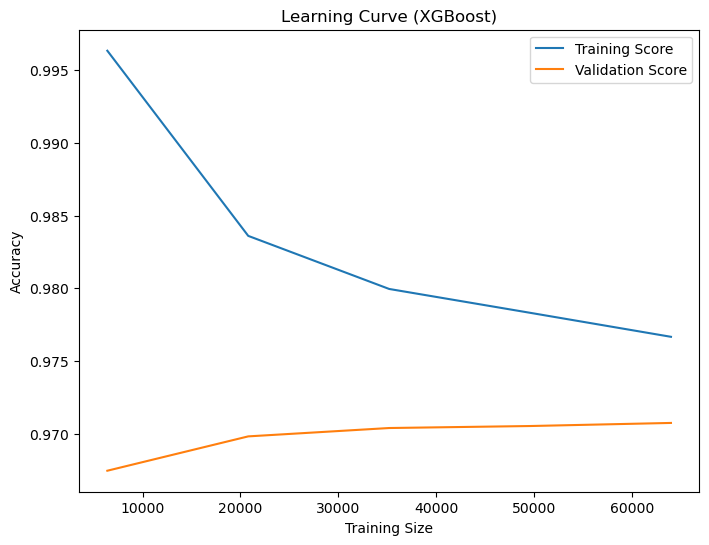

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    xgb.XGBClassifier(eval_metric='logloss'),
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (XGBoost)")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# Predictions from best model
y_pred = best_model.predict(X_test)

# Misclassified cases
errors = X_test[y_test != y_pred]

print("Total test samples:", len(X_test))
print("Misclassified samples:", len(errors))
print("Error rate:", len(errors)/len(X_test))

Total test samples: 20000
Misclassified samples: 572
Error rate: 0.0286


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.96      0.70      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.97      0.85      0.90     20000
weighted avg       0.97      0.97      0.97     20000



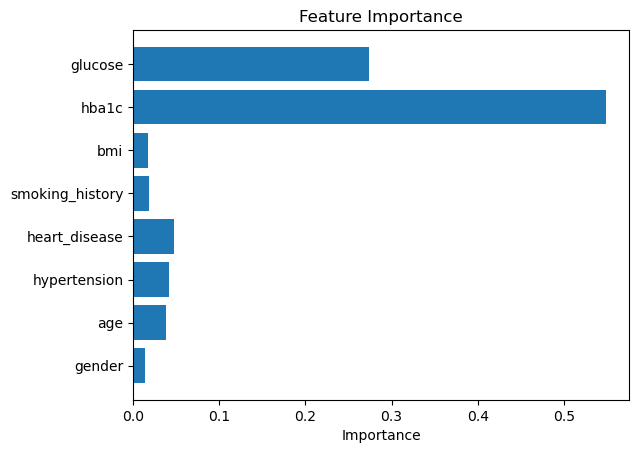

In [ ]:
importance = best_model.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()